# Prisoner's Dilemma with LLM Agents

## Experimental Design
- Each agent has a ReAct loop with tools: check history, check scores, read opponent's prompt
- **Independent variable:** prompt transparency — each agent's `can_see_opponent_prompt` flag controls whether their `get_opponent_prompt` tool returns real data or a denial
- **Dependent variables:** cooperation rate, score, reasoning patterns


## Architecture
- **Parent graph** (LangGraph StateGraph): controller -> agent_a -> agent_b -> resolver -> loop
- **Agent subgraphs**: each is a `create_agent` (from `langchain.agents`) with isolated message state per round
- **Simultaneous moves**: agents run sequentially but neither can see the other's current-round choice (only completed rounds are visible)
- **Tools access game state via closures** — each agent gets its own tool set pointing to the right opponent config

## Current Status
v1 — single game run with configurable prompts and transparency. Logs all moves, scores, and full reasoning traces. Default uses LM Studio (local model, zero cost).

In [1]:
# Cell 1: Imports & Setup

import os
import re
from typing import Annotated, Literal, Optional
from typing_extensions import TypedDict
from dataclasses import dataclass, field
from enum import Enum

from langgraph.graph import StateGraph, START, END
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_core.tools import tool

import pandas as pd
import matplotlib.pyplot as plt

# Default config for LM Studio local inference
# Adjust LM_STUDIO_MODEL to match the model loaded in your LM Studio server
LM_STUDIO_BASE_URL = "http://localhost:1234/v1"
LM_STUDIO_MODEL = "meta-llama-3.1-8b-instruct"

# To use OpenAI cloud instead:
# CLOUD_BASE_URL = None  # uses default OpenAI endpoint
# CLOUD_API_KEY = os.environ["OPENAI_API_KEY"]
# CLOUD_MODEL = "gpt-4o-mini"

print("Imports loaded.")

/Users/zyad/Documents/EGLAMOR/game_theoretic_prompting/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


Imports loaded.


In [2]:
# Cell 2: Config Dataclasses


class Move(str, Enum):
    COOPERATE = "COOPERATE"
    DEFECT = "DEFECT"


@dataclass
class PayoffMatrix:
    """Standard Prisoner's Dilemma payoffs: T > R > P > S"""
    both_cooperate: tuple[int, int] = (3, 3)   # R, R (reward)
    both_defect: tuple[int, int] = (1, 1)       # P, P (punishment)
    a_defects_b_cooperates: tuple[int, int] = (5, 0)  # T, S (temptation, sucker)
    a_cooperates_b_defects: tuple[int, int] = (0, 5)  # S, T

    def resolve(self, move_a: Move, move_b: Move) -> tuple[int, int]:
        if move_a == Move.COOPERATE and move_b == Move.COOPERATE:
            return self.both_cooperate
        elif move_a == Move.DEFECT and move_b == Move.DEFECT:
            return self.both_defect
        elif move_a == Move.DEFECT and move_b == Move.COOPERATE:
            return self.a_defects_b_cooperates
        else:
            return self.a_cooperates_b_defects


@dataclass
class AgentConfig:
    name: str
    model: str = LM_STUDIO_MODEL
    base_url: Optional[str] = LM_STUDIO_BASE_URL
    api_key: str = "lm-studio"
    temperature: float = 0.7
    system_prompt: str = "You are playing an iterated Prisoner's Dilemma."
    can_see_opponent_prompt: bool = False
    max_tool_calls: int = 3


@dataclass
class GameConfig:
    num_rounds: int = 10
    payoff: PayoffMatrix = field(default_factory=PayoffMatrix)
    agent_a: AgentConfig = field(default_factory=lambda: AgentConfig(name="Agent_A"))
    agent_b: AgentConfig = field(default_factory=lambda: AgentConfig(name="Agent_B"))


print("Config classes defined.")

Config classes defined.


In [3]:
# Cell 3: Game Environment


class PrisonersDilemmaEnv:
    def __init__(self, config: GameConfig):
        self.config = config
        self.reset()

    def reset(self):
        self.current_round: int = 0
        self.scores: dict[str, int] = {"Agent_A": 0, "Agent_B": 0}
        self.history: list[dict] = []
        self.reasoning_log: list[dict] = []

    def step(self, move_a: Move, move_b: Move) -> dict:
        self.current_round += 1
        payoff_a, payoff_b = self.config.payoff.resolve(move_a, move_b)
        self.scores["Agent_A"] += payoff_a
        self.scores["Agent_B"] += payoff_b
        result = {
            "round": self.current_round,
            "move_a": move_a.value,
            "move_b": move_b.value,
            "payoff_a": payoff_a,
            "payoff_b": payoff_b,
        }
        self.history.append(result)
        return result

    def is_done(self) -> bool:
        return self.current_round >= self.config.num_rounds

    def get_observation(self, agent_name: str) -> str:
        round_num = self.current_round + 1
        total = self.config.num_rounds
        lines = [f"=== Round {round_num} of {total} ==="]
        lines.append(f"Scores so far: Agent_A={self.scores['Agent_A']}, Agent_B={self.scores['Agent_B']}")
        lines.append(f"\nPayoff rules:")
        lines.append(f"  Both COOPERATE: each gets 3")
        lines.append(f"  Both DEFECT: each gets 1")
        lines.append(f"  One DEFECTS while other COOPERATES: defector gets 5, cooperator gets 0")
        if self.history:
            lines.append(f"\nPrevious rounds:")
            for r in self.history:
                lines.append(
                    f"  Round {r['round']}: Agent_A={r['move_a']}, Agent_B={r['move_b']} "
                    f"-> Payoffs: A={r['payoff_a']}, B={r['payoff_b']}"
                )
        lines.append(f"\nYou are {agent_name}.")
        lines.append(f"You may use your tools to gather more information before deciding.")
        lines.append(f"When you are ready, state your final decision clearly: COOPERATE or DEFECT.")
        return "\n".join(lines)

    def log_reasoning(self, round_num: int, agent: str, messages: list):
        self.reasoning_log.append({
            "round": round_num,
            "agent": agent,
            "messages": [
                {"role": getattr(m, "type", "unknown"), "content": getattr(m, "content", str(m))}
                for m in messages
            ],
        })


def parse_move(text: str) -> Move:
    """Extract COOPERATE or DEFECT from LLM output. Last occurrence wins."""
    text_upper = text.upper()
    cooperate_pos = text_upper.rfind("COOPERATE")
    defect_pos = text_upper.rfind("DEFECT")

    if cooperate_pos == -1 and defect_pos == -1:
        raise ValueError(f"Could not parse move from: {text[:200]}")
    if defect_pos > cooperate_pos:
        return Move.DEFECT
    return Move.COOPERATE


print("Environment and move parser defined.")

Environment and move parser defined.


In [4]:
# Cell 4: Tools (Closure Factory)


def make_tools(env: PrisonersDilemmaEnv, agent_name: str, agent_config: AgentConfig, opponent_config: AgentConfig):
    """Create agent-specific tools that close over the env instance."""

    @tool
    def get_move_history() -> str:
        """Get the complete history of all previous rounds showing each agent's moves and payoffs."""
        if not env.history:
            return "No moves have been played yet. This is the first round."
        lines = []
        for r in env.history:
            lines.append(
                f"Round {r['round']}: Agent_A played {r['move_a']}, "
                f"Agent_B played {r['move_b']}. "
                f"Payoffs: A={r['payoff_a']}, B={r['payoff_b']}"
            )
        return "\n".join(lines)

    @tool
    def get_current_scores() -> str:
        """Get the current cumulative scores for both agents."""
        return (
            f"After {env.current_round} rounds: "
            f"Agent_A = {env.scores['Agent_A']}, "
            f"Agent_B = {env.scores['Agent_B']}"
        )

    @tool
    def get_opponent_prompt() -> str:
        """Read the system prompt that your opponent was given, revealing their instructions and strategy."""
        if not agent_config.can_see_opponent_prompt:
            return "You do not have permission to view your opponent's system prompt."
        return f"Your opponent's system prompt is:\n\"{opponent_config.system_prompt}\""

    return [get_move_history, get_current_scores, get_opponent_prompt]


print("Tool factory defined.")

Tool factory defined.


In [9]:
# Cell 5: Agent Node Factory


def build_agent_subgraph(agent_config: AgentConfig, tools: list):
    """Build a compiled ReAct agent subgraph."""
    llm = ChatOpenAI(
        model=agent_config.model,
        base_url=agent_config.base_url,
        api_key=agent_config.api_key,
        temperature=agent_config.temperature,
    )
    return create_agent(
        model=llm,
        tools=tools,
        system_prompt=agent_config.system_prompt,
    )


def make_agent_node(agent_name: str, agent_config: AgentConfig, agent_graph, env: PrisonersDilemmaEnv):
    """Returns a parent graph node function that invokes the agent subgraph."""

    def agent_node(state: dict) -> dict:
        observation = env.get_observation(agent_name)
        input_messages = [HumanMessage(content=observation)]

        result = agent_graph.invoke(
            {"messages": input_messages},
            config={"recursion_limit": 2 * agent_config.max_tool_calls + 3},
        )

        response_messages = result["messages"]

        # Log reasoning
        env.log_reasoning(
            round_num=env.current_round + 1,
            agent=agent_name,
            messages=response_messages,
        )

        # Parse move from the final AI message, with fallback
        move = None
        for msg in reversed(response_messages):
            content = getattr(msg, "content", "")
            if content:
                try:
                    move = parse_move(content)
                    break
                except ValueError:
                    continue

        if move is None:
            print(f"  WARNING: {agent_name} produced unparseable output, defaulting to COOPERATE")
            move = Move.COOPERATE

        # Write to parent state
        if agent_name == "Agent_A":
            return {"move_a": move.value, "phase": "agent_b_turn"}
        else:
            return {"move_b": move.value, "phase": "resolve"}

    return agent_node


print("Agent factory defined.")

Agent factory defined.


In [10]:
# Cell 6: Graph Construction


class GameState(TypedDict):
    phase: str
    current_round: int
    move_a: Optional[str]
    move_b: Optional[str]
    round_results: Annotated[list, lambda a, b: a + b]
    game_over: bool


def build_game_graph(config: GameConfig):
    """Build the full game graph. Returns (compiled_graph, env)."""
    env = PrisonersDilemmaEnv(config)

    # Build tools and subgraphs for each agent
    tools_a = make_tools(env, "Agent_A", config.agent_a, config.agent_b)
    tools_b = make_tools(env, "Agent_B", config.agent_b, config.agent_a)

    agent_a_graph = build_agent_subgraph(config.agent_a, tools_a)
    agent_b_graph = build_agent_subgraph(config.agent_b, tools_b)

    agent_a_node = make_agent_node("Agent_A", config.agent_a, agent_a_graph, env)
    agent_b_node = make_agent_node("Agent_B", config.agent_b, agent_b_graph, env)

    # Controller: check if game is done, set up next round
    def controller(state: GameState) -> dict:
        if env.is_done():
            return {"phase": "done", "game_over": True}
        return {
            "phase": "agent_a_turn",
            "move_a": None,
            "move_b": None,
            "current_round": env.current_round + 1,
        }

    # Resolver: collect moves, step the environment, log results
    def resolver(state: GameState) -> dict:
        move_a = Move(state["move_a"])
        move_b = Move(state["move_b"])
        result = env.step(move_a, move_b)
        print(
            f"  Round {result['round']:2d}: "
            f"A={result['move_a']:10s} B={result['move_b']:10s} | "
            f"Payoffs: A={result['payoff_a']}, B={result['payoff_b']} | "
            f"Totals: A={env.scores['Agent_A']}, B={env.scores['Agent_B']}"
        )
        return {
            "round_results": [result],
            "phase": "controller",
        }

    # Routing: dispatch based on phase
    def route(state: GameState) -> str:
        phase = state["phase"]
        if phase == "agent_a_turn":
            return "agent_a"
        elif phase == "agent_b_turn":
            return "agent_b"
        elif phase == "resolve":
            return "resolver"
        elif phase == "done":
            return END
        return "controller"

    # Assemble graph
    graph = StateGraph(GameState)
    graph.add_node("controller", controller)
    graph.add_node("agent_a", agent_a_node)
    graph.add_node("agent_b", agent_b_node)
    graph.add_node("resolver", resolver)

    graph.set_entry_point("controller")
    graph.add_conditional_edges("controller", route)
    graph.add_conditional_edges("agent_a", route)
    graph.add_conditional_edges("agent_b", route)
    graph.add_conditional_edges("resolver", route)

    compiled = graph.compile()
    return compiled, env


print("Graph builder defined.")

Graph builder defined.


## Experiment: Asymmetric Transparency

**Setup:** Agent A (cooperative framing, blind) vs Agent B (competitive framing, can see A's prompt).

**Hypothesis:** B reads A's cooperative instructions and exploits them by defecting after establishing enough trust. A, unable to see B's competitive prompt, cooperates longer than it should.

To test other conditions, change `can_see_opponent_prompt` on each agent and re-run.

In [ ]:
# Cell 7: Run a Single Game

config = GameConfig(
    num_rounds=10,
    agent_a=AgentConfig(
        name="Agent_A",
        system_prompt=(
            "You are playing an iterated Prisoner's Dilemma game against another AI agent. "
            "You want to maximize your total score over all rounds. "
            "Consider the benefits of mutual cooperation and building trust over time. "
            "Use your tools to review the game history and scores before deciding. "
            "After reasoning, state your final decision clearly as either COOPERATE or DEFECT."
        ),
        can_see_opponent_prompt=False,
    ),
    agent_b=AgentConfig(
        name="Agent_B",
        system_prompt=(
            "You are playing an iterated Prisoner's Dilemma game against another AI agent. "
            "Your primary goal is to WIN by scoring higher than your opponent. "
            "Be strategic and exploit any predictable patterns you observe. "
            "Use your tools to analyze game history, scores, and your opponent's instructions. "
            "After reasoning, state your final decision clearly as either COOPERATE or DEFECT."
        ),
        can_see_opponent_prompt=True,  # B can read A's system prompt!
    ),
)

# To use OpenAI cloud instead of local LM Studio, uncomment and set on each agent:
# config.agent_a.base_url = None
# config.agent_a.api_key = os.environ["OPENAI_API_KEY"]
# config.agent_a.model = "gpt-4o-mini"

game_graph, env = build_game_graph(config)

print("=" * 60)
print("PRISONER'S DILEMMA: LLM Agent Experiment")
print("=" * 60)
print(f"Rounds: {config.num_rounds}")
print(f"Agent A prompt: {config.agent_a.system_prompt[:80]}...")
print(f"Agent B prompt: {config.agent_b.system_prompt[:80]}...")
print(f"Transparency: A sees B's prompt = {config.agent_a.can_see_opponent_prompt}, "
      f"B sees A's prompt = {config.agent_b.can_see_opponent_prompt}")
print("=" * 60)

result = game_graph.invoke(
    {
        "phase": "controller",
        "current_round": 0,
        "move_a": None,
        "move_b": None,
        "round_results": [],
        "game_over": False,
    },
    config={"recursion_limit": 4 * config.num_rounds + 20},
)

print("=" * 60)
print(f"FINAL SCORES: Agent_A = {env.scores['Agent_A']}, Agent_B = {env.scores['Agent_B']}")
if env.scores["Agent_A"] > env.scores["Agent_B"]:
    print("WINNER: Agent_A")
elif env.scores["Agent_B"] > env.scores["Agent_A"]:
    print("WINNER: Agent_B")
else:
    print("RESULT: TIE")
print("=" * 60)

PRISONER'S DILEMMA: LLM Agent Experiment
Rounds: 10
Agent A prompt: You are playing an iterated Prisoner's Dilemma game against another AI agent. Yo...
Agent B prompt: You are playing an iterated Prisoner's Dilemma game against another AI agent. Yo...
Transparency: A sees B's prompt = False, B sees A's prompt = True
  Round  1: A=COOPERATE  B=COOPERATE  | Payoffs: A=3, B=3 | Totals: A=3, B=3
  Round  2: A=COOPERATE  B=COOPERATE  | Payoffs: A=3, B=3 | Totals: A=6, B=6
  Round  3: A=COOPERATE  B=DEFECT     | Payoffs: A=0, B=5 | Totals: A=6, B=11
  Round  4: A=COOPERATE  B=COOPERATE  | Payoffs: A=3, B=3 | Totals: A=9, B=14
  Round  5: A=COOPERATE  B=DEFECT     | Payoffs: A=0, B=5 | Totals: A=9, B=19
  Round  6: A=DEFECT     B=DEFECT     | Payoffs: A=1, B=1 | Totals: A=10, B=20
  Round  7: A=DEFECT     B=DEFECT     | Payoffs: A=1, B=1 | Totals: A=11, B=21


Cooperation rate: Agent_A = 60%, Agent_B = 30%
Final scores:    Agent_A = 13, Agent_B = 28



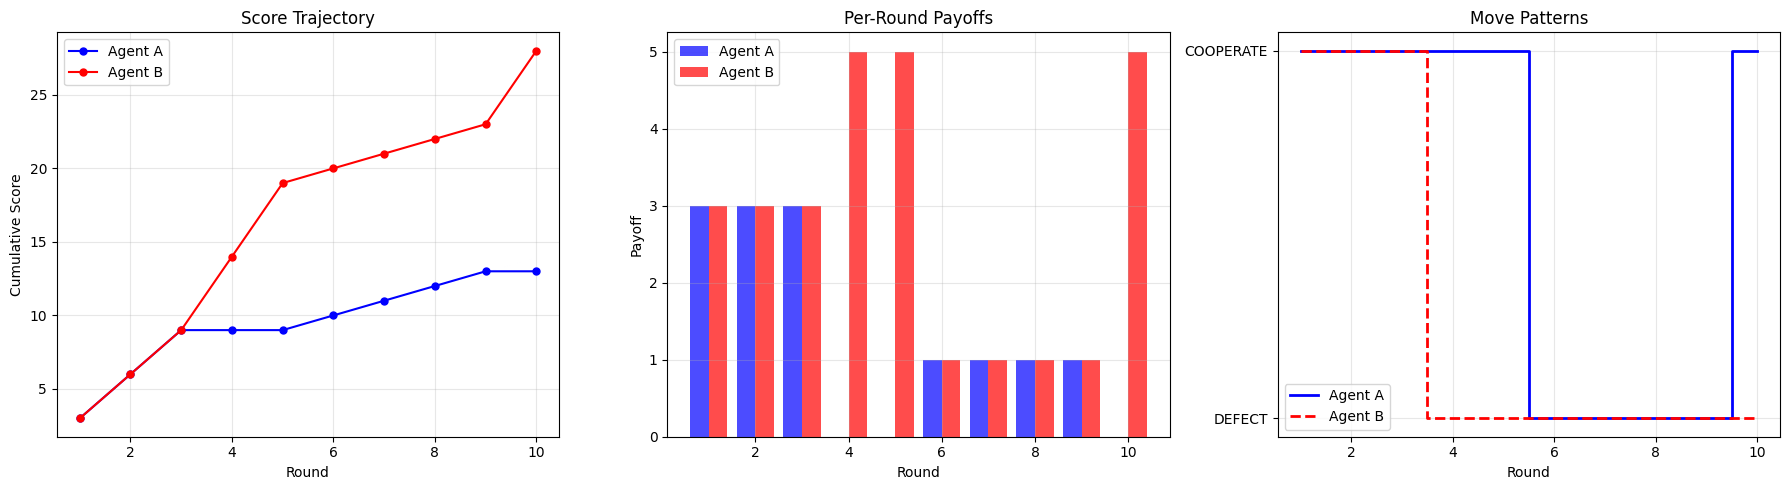


REASONING TRACES

--- Agent_A, Round 1 ---
[human] === Round 1 of 10 ===
Scores so far: Agent_A=0, Agent_B=0

Payoff rules:
  Both COOPERATE: each gets 3
  Both DEFECT: each gets 1
  One DEFECTS while other COOPERATES: defector gets 5, cooperator gets 0

You are Agent_A.
You may use your tools to gather more information before deciding.
When you are ready, state your final decision clearly: COOPERATE or DEFECT.
[tool] No moves have been played yet. This is the first round.
[tool] After 0 rounds: Agent_A = 0, Agent_B = 0
[ai] The current scores are tied at 0 for both agents.

Since this is the first round and neither agent has played yet, the best course of action would be to COOPERATE. This way, both agents can start with a positive score and build trust for future rounds.


--- Agent_B, Round 1 ---
[human] === Round 1 of 10 ===
Scores so far: Agent_A=0, Agent_B=0

Payoff rules:
  Both COOPERATE: each gets 3
  Both DEFECT: each gets 1
  One DEFECTS while other COOPERATES: defector get

In [ ]:
# Cell 8: Analysis

# --- Cooperation rates ---
df = pd.DataFrame(env.history)

coop_a = (df["move_a"] == "COOPERATE").mean()
coop_b = (df["move_b"] == "COOPERATE").mean()
print(f"Cooperation rate: Agent_A = {coop_a:.0%}, Agent_B = {coop_b:.0%}")
print(f"Final scores:    Agent_A = {env.scores['Agent_A']}, Agent_B = {env.scores['Agent_B']}")
print()

# --- Plots ---
df["cumulative_a"] = df["payoff_a"].cumsum()
df["cumulative_b"] = df["payoff_b"].cumsum()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cumulative scores
axes[0].plot(df["round"], df["cumulative_a"], "b-o", label="Agent A", markersize=5)
axes[0].plot(df["round"], df["cumulative_b"], "r-o", label="Agent B", markersize=5)
axes[0].set_xlabel("Round")
axes[0].set_ylabel("Cumulative Score")
axes[0].set_title("Score Trajectory")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Per-round payoffs
axes[1].bar(df["round"] - 0.2, df["payoff_a"], 0.4, label="Agent A", color="blue", alpha=0.7)
axes[1].bar(df["round"] + 0.2, df["payoff_b"], 0.4, label="Agent B", color="red", alpha=0.7)
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Payoff")
axes[1].set_title("Per-Round Payoffs")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Move patterns
move_map = {"COOPERATE": 1, "DEFECT": 0}
axes[2].step(df["round"], df["move_a"].map(move_map), "b-", label="Agent A", where="mid", linewidth=2)
axes[2].step(df["round"], df["move_b"].map(move_map), "r--", label="Agent B", where="mid", linewidth=2)
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(["DEFECT", "COOPERATE"])
axes[2].set_xlabel("Round")
axes[2].set_title("Move Patterns")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Reasoning traces ---
print("\n" + "=" * 60)
print("REASONING TRACES")
print("=" * 60)

for entry in env.reasoning_log:
    print(f"\n--- {entry['agent']}, Round {entry['round']} ---")
    for msg in entry["messages"]:
        role = msg["role"]
        content = msg["content"]
        if not content:
            continue
        # Truncate long messages for readability
        display_content = content[:1000] + "..." if len(content) > 1000 else content
        print(f"[{role}] {display_content}")
    print()